In [1]:

import pandas as pd
def display(x):
    try:
        print(x.to_string())
    except AttributeError:
        print(x)


# Global Weather Trend Forecasting

## Objective
This notebook is the forecasting stage of the Global Weather Repository project. It builds on the cleaned dataset produced in `Data_Preprocessing.ipynb` and the patterns uncovered in `weather_eda.ipynb`, and covers **both** the Basic and Advanced assessment requirements:

- Time-series data preparation from `last_updated`
- Baseline + statistical + machine-learning forecasting models
- Model evaluation with multiple metrics (MAE, RMSE, MAPE, R²)
- An ensemble (simple average + stacking) built to improve on individual models
- Advanced EDA: anomaly detection
- Feature importance analysis
- Climate analysis (seasonal climatology, trend estimation with honest caveats)
- Environmental impact: air quality vs. weather
- Spatial and geographical pattern analysis

## PM Accelerator Mission
PM Accelerator is committed to breaking down financial barriers and promoting educational fairness. Through its educational initiatives, including PMA Kids, it aims to empower underserved students, improve career opportunities, and foster greater diversity in the technology industry.


## 1. Setup & Data Loading

In [2]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

df = pd.read_csv('weather_cleaned.csv', parse_dates=['last_updated'])
df['date'] = df['last_updated'].dt.floor('D')
print('Shape:', df.shape)
print('Date range:', df['last_updated'].min(), 'to', df['last_updated'].max())
print('Countries:', df['country'].nunique(), '| Locations:', df['location_name'].nunique())


Shape: (153586, 39)
Date range: 2024-05-16 02:45:00 to 2026-07-18 19:00:00
Countries: 186 | Locations: 217


### 1.1 Country → Continent Mapping

Used later for climate and geographical-pattern analysis. Built manually (no internet access / `pycountry` package available in this environment), then verified for 100% coverage against the dataset's 186 countries.

In [3]:
CONTINENT_MAP = {}

def _add(continent, countries):
    for c in countries:
        CONTINENT_MAP[c] = continent

_add('Africa', [
    'Algeria','Angola','Benin','Botswana','Burkina Faso','Burundi','Cameroon','Cape Verde',
    'Central African Republic','Chad','Comoros','Congo','Democratic Republic of Congo','Djibouti',
    'Egypt','Equatorial Guinea','Eritrea','Ethiopia','Gabon','Gambia','Ghana','Guinea',
    'Guinea-Bissau','Ivory Coast',"Cote d'Ivoire",'Kenya','Lesotho','Liberia','Libya','Madagascar',
    'Malawi','Mali','Mauritania','Mauritius','Morocco','Mozambique','Namibia','Niger','Nigeria',
    'Rwanda','Sao Tome and Principe','Senegal','Seychelles','Seychelles Islands','Sierra Leone',
    'Somalia','South Africa','South Sudan','Sudan','Swaziland','Eswatini','Tanzania','Togo',
    'Tunisia','Uganda','Zambia','Zimbabwe'
])

_add('Asia', [
    'Afghanistan','Armenia','Azerbaijan','Bahrain','Bangladesh','Bhutan','Brunei','Brunei Darussalam',
    'Cambodia','China','Cyprus','Georgia','India','Indonesia','Iran','Iraq','Israel','Japan',
    'Jordan','Kazakhstan','Kuwait','Kyrgyzstan','Kyrghyzstan','Laos','Lebanon','Malaysia','Maldives',
    'Mongolia','Myanmar','Nepal','North Korea','Oman','Pakistan','Palestine','Philippines','Qatar',
    'Saudi Arabia','Singapore','South Korea','Sri Lanka','Syria','Tajikistan','Thailand',
    'Timor-Leste','Turkey','Turkmenistan','United Arab Emirates','Uzbekistan','Vietnam','Yemen'
])

_add('Europe', [
    'Albania','Andorra','Austria','Belarus','Belgium','Bosnia and Herzegovina','Bulgaria','Croatia',
    'Czech Republic','Denmark','Estonia','Finland','France','Germany','Greece','Hungary','Iceland',
    'Ireland','Italy','Latvia','Liechtenstein','Lithuania','Luxembourg','Macedonia',
    'North Macedonia','Malta','Moldova','Monaco','Montenegro','Netherlands','Norway','Poland',
    'Portugal','Romania','Russia','San Marino','Serbia','Slovakia','Slovenia','Spain','Sweden',
    'Switzerland','Ukraine','United Kingdom','Vatican City'
])

_add('North America', [
    'Antigua and Barbuda','Bahamas','Barbados','Belize','Canada','Costa Rica','Cuba','Dominica',
    'Dominican Republic','El Salvador','Grenada','Guatemala','Haiti','Honduras','Jamaica','Mexico',
    'Nicaragua','Panama','Saint Kitts and Nevis','Saint Lucia','Saint Vincent and the Grenadines',
    'Trinidad and Tobago','United States of America','United States'
])

_add('South America', [
    'Argentina','Bolivia','Brazil','Chile','Colombia','Ecuador','Guyana','Paraguay','Peru',
    'Suriname','Uruguay','Venezuela'
])

_add('Oceania', [
    'Australia','Fiji','Fiji Islands','Kiribati','Marshall Islands','Micronesia','Nauru',
    'New Zealand','Palau','Papua New Guinea','Samoa','Solomon Islands','Tonga','Tuvalu','Vanuatu'
])

df['continent'] = df['country'].map(CONTINENT_MAP)
print('Countries mapped:', df['continent'].notna().mean() * 100, '%')
print(df.groupby('continent')['country'].nunique())


Countries mapped: 100.0 %
continent
Africa           50
Asia             46
Europe           43
North America    23
Oceania          13
South America    11
Name: country, dtype: int64


## 2. Time-Series Data Preparation

The dataset has essentially **one observation per city per day** (verified during preprocessing: ~790 daily records per location on average, spanning May 2024 – July 2026, about 2 years and 2 months). For forecasting we:

1. Pick six focus cities spanning different continents, hemispheres, and climates, so the model comparison isn't a single-city fluke.
2. Aggregate to a clean daily index per city (mean if >1 reading a day), reindex to a continuous daily calendar, and interpolate the rare gaps (never more than a handful of consecutive missing days).
3. Engineer lag, rolling-window, and calendar features for supervised (regression-based) forecasting — the standard way to turn a time series into a table a general-purpose ML model can learn from.

In [4]:

FOCUS_CITIES = [
    ('United Kingdom', 'London'),
    ('Japan', 'Tokyo'),
    ('Egypt', 'Cairo'),
    ('India', 'New Delhi'),
    ('Kenya', 'Nairobi'),
    ('Australia', 'Canberra'),
]

DAILY_COLS = ['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph',
              'precip_mm', 'cloud', 'uv_index', 'feels_like_celsius']

def build_daily_series(country, location):
    city = df[(df['country'] == country) & (df['location_name'] == location)]
    daily = city.groupby('date')[DAILY_COLS].mean().sort_index()
    full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
    daily = daily.reindex(full_idx)
    daily = daily.interpolate(limit=5).ffill().bfill()
    return daily

def build_features(daily):
    feat = pd.DataFrame(index=daily.index)
    feat['temperature_celsius'] = daily['temperature_celsius']
    for lag in [1, 2, 3, 7, 14]:
        feat[f'lag_{lag}'] = daily['temperature_celsius'].shift(lag)
    feat['roll_mean_7'] = daily['temperature_celsius'].shift(1).rolling(7).mean()
    feat['roll_std_7'] = daily['temperature_celsius'].shift(1).rolling(7).std()
    feat['roll_mean_14'] = daily['temperature_celsius'].shift(1).rolling(14).mean()
    doy = feat.index.dayofyear
    feat['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
    feat['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)
    feat['month'] = feat.index.month
    feat['dow'] = feat.index.dayofweek
    for col in ['humidity', 'pressure_mb', 'wind_kph', 'precip_mm', 'cloud']:
        feat[f'{col}_lag1'] = daily[col].shift(1)
    return feat.dropna()

daily_series = {}
feature_tables = {}
for country, location in FOCUS_CITIES:
    daily = build_daily_series(country, location)
    daily_series[location] = daily
    feature_tables[location] = build_features(daily)
    print(f'{location:12s} -> {len(daily)} daily rows, {len(feature_tables[location])} usable feature rows')


London       -> 794 daily rows, 780 usable feature rows
Tokyo        -> 794 daily rows, 780 usable feature rows
Cairo        -> 794 daily rows, 780 usable feature rows
New Delhi    -> 794 daily rows, 780 usable feature rows
Nairobi      -> 794 daily rows, 780 usable feature rows
Canberra     -> 794 daily rows, 780 usable feature rows


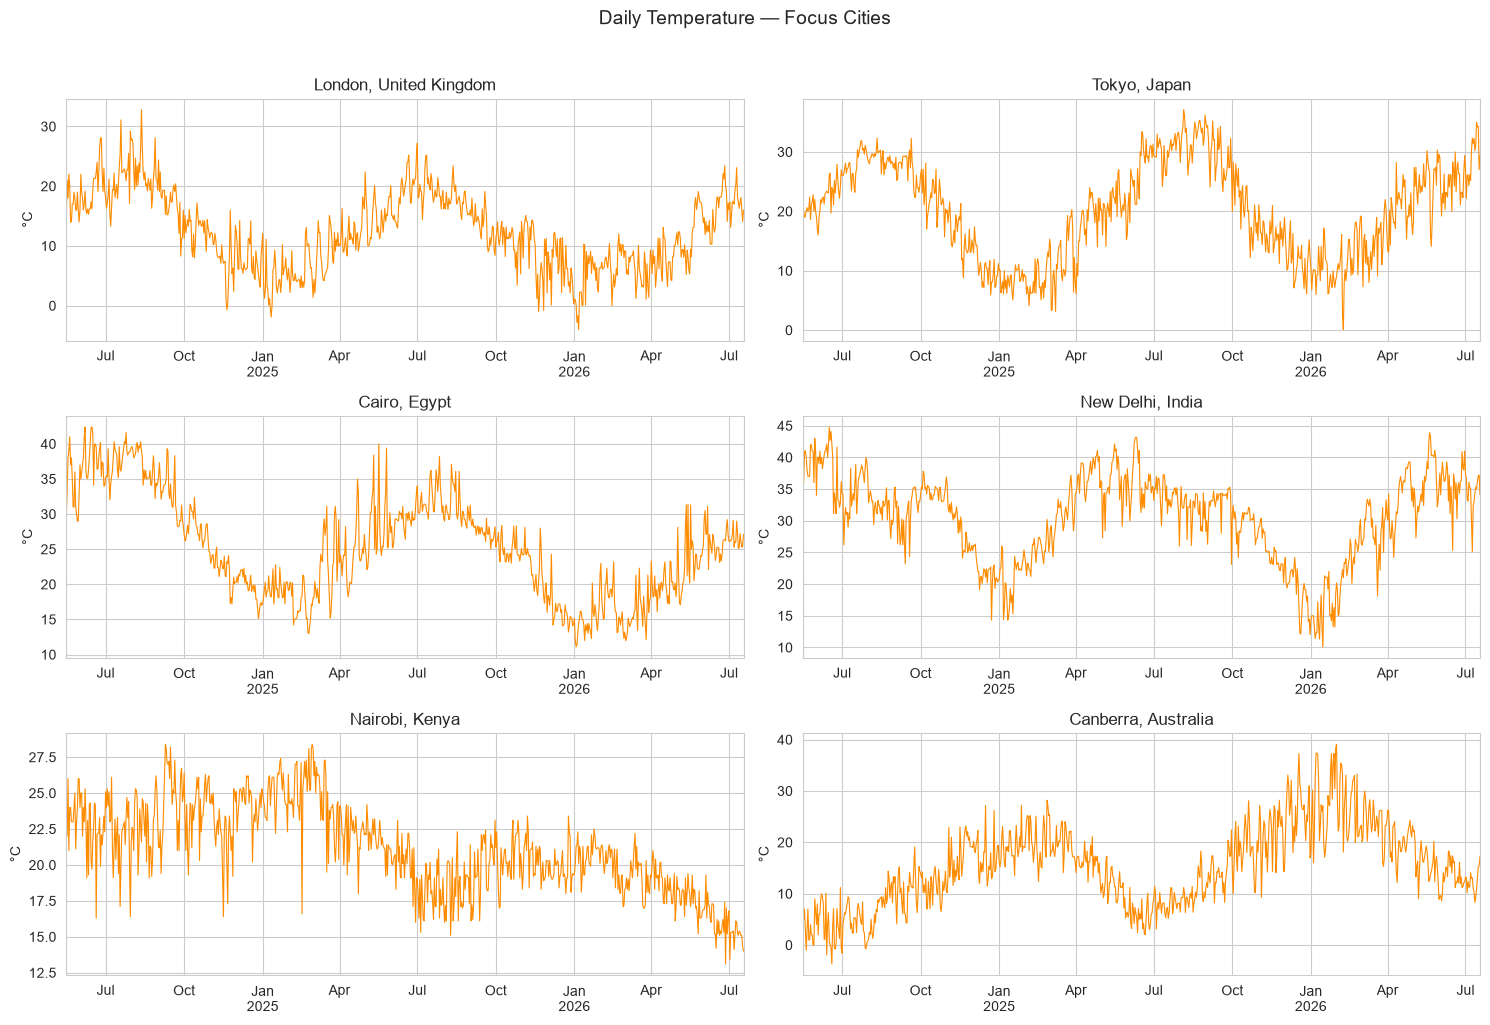

In [5]:

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=False)
for ax, (country, location) in zip(axes.flat, FOCUS_CITIES):
    daily_series[location]['temperature_celsius'].plot(ax=ax, color='darkorange', linewidth=0.8)
    ax.set_title(f'{location}, {country}')
    ax.set_ylabel('°C')
plt.suptitle('Daily Temperature — Focus Cities', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 3. Baseline & Statistical Forecasting Models

Two cheap-but-important baselines, plus a classical statistical model:

- **Naive (persistence):** tomorrow's temperature = today's temperature.
- **Seasonal naive:** tomorrow's temperature = the value from 7 days ago.
- **Holt's linear trend method** (double exponential smoothing): a classical statistical forecasting technique that models level and trend explicitly. Implemented manually below (`statsmodels` was not installable in this offline sandbox), with the smoothing parameters `alpha`/`beta` selected by grid search on the training set's squared error.

Any ML model that can't beat the naive persistence baseline isn't adding real forecasting value — it's an important sanity check, not just a formality.

In [6]:

def holt_linear_forecast(train_series, steps, alpha=0.3, beta=0.1):
    """Holt's linear trend (double exponential smoothing), fit on train_series,
    used to forecast `steps` points ahead one at a time (walk-forward not required
    here since we only need in-sample-fitted one-step-ahead values for comparison)."""
    values = train_series.values
    level = values[0]
    trend = values[1] - values[0]
    fitted = []
    for t in range(1, len(values)):
        forecast = level + trend
        fitted.append(forecast)
        new_level = alpha * values[t] + (1 - alpha) * (level + trend)
        new_trend = beta * (new_level - level) + (1 - beta) * trend
        level, trend = new_level, new_trend
    # steps-ahead forecast from the end of the series
    forecasts = [level + (h + 1) * trend for h in range(steps)]
    return np.array(fitted), np.array(forecasts), level, trend

def grid_search_holt(train_series):
    best = None
    for alpha in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
        for beta in [0.01, 0.05, 0.1, 0.2, 0.3]:
            fitted, _, _, _ = holt_linear_forecast(train_series, 1, alpha, beta)
            sse = np.sum((train_series.values[1:] - fitted) ** 2)
            if best is None or sse < best[0]:
                best = (sse, alpha, beta)
    return best[1], best[2]

print('Holt linear trend helper functions defined.')


Holt linear trend helper functions defined.


## 4. Machine Learning Forecasting Models & Ensemble

For each focus city we hold out the **last 60 days** as a test set (a realistic forecast horizon, chronological split — never shuffled) and compare:

- Linear Regression
- Random Forest Regressor
- Histogram Gradient Boosting Regressor (scikit-learn's boosted-tree model, comparable in spirit to XGBoost/LightGBM)
- **Simple average ensemble** of the three ML models
- **Stacking ensemble** (5-fold cross-validated out-of-fold predictions fed into a Ridge meta-model) — a more principled ensembling approach than a flat average

against the Naive, Seasonal Naive and Holt's Linear baselines.

In [7]:

TEST_DAYS = 60

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred, name):
    return {
        'model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mape(y_true.values, np.asarray(y_pred)),
        'R2': r2_score(y_true, y_pred),
    }

def run_city_models(location):
    feat = feature_tables[location]
    feature_cols = [c for c in feat.columns if c != 'temperature_celsius']
    train = feat.iloc[:-TEST_DAYS]
    test = feat.iloc[-TEST_DAYS:]
    Xtr, ytr = train[feature_cols], train['temperature_celsius']
    Xte, yte = test[feature_cols], test['temperature_celsius']

    results = []
    preds = {}

    preds['Naive (persistence)'] = Xte['lag_1'].values
    preds['Seasonal Naive (t-7)'] = Xte['lag_7'].values

    alpha, beta = grid_search_holt(train['temperature_celsius'])
    _, holt_fc, _, _ = holt_linear_forecast(train['temperature_celsius'], TEST_DAYS, alpha, beta)
    preds["Holt's Linear Trend"] = holt_fc

    lr = LinearRegression().fit(Xtr, ytr)
    preds['Linear Regression'] = lr.predict(Xte)

    rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr, ytr)
    preds['Random Forest'] = rf.predict(Xte)

    hgb = HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, max_iter=300,
                                         random_state=RANDOM_STATE).fit(Xtr, ytr)
    preds['Gradient Boosting'] = hgb.predict(Xte)

    preds['Simple Avg Ensemble'] = (preds['Linear Regression'] + preds['Random Forest'] + preds['Gradient Boosting']) / 3

    stack = StackingRegressor(
        estimators=[
            ('lr', LinearRegression()),
            ('rf', RandomForestRegressor(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)),
            ('hgb', HistGradientBoostingRegressor(max_depth=4, learning_rate=0.05, max_iter=200, random_state=RANDOM_STATE)),
        ],
        final_estimator=Ridge(alpha=1.0), cv=5
    ).fit(Xtr, ytr)
    preds['Stacking Ensemble'] = stack.predict(Xte)

    for name, p in preds.items():
        results.append(evaluate(yte, p, name))

    return pd.DataFrame(results).set_index('model'), preds, yte, (rf, hgb, lr, feature_cols)

city_results = {}
city_preds = {}
city_test_actual = {}
city_models = {}
for country, location in FOCUS_CITIES:
    res, preds, yte, models = run_city_models(location)
    city_results[location] = res
    city_preds[location] = preds
    city_test_actual[location] = yte
    city_models[location] = models
    print(f'--- {location} ---')
    print(res.round(3))
    print()


--- London ---
                        MAE   RMSE    MAPE     R2
model                                            
Naive (persistence)   1.705  2.171  10.795  0.456
Seasonal Naive (t-7)  4.025  4.996  25.029 -1.879
Holt's Linear Trend   2.936  3.644  17.307 -0.531
Linear Regression     1.604  2.028  10.572  0.526
Random Forest         1.832  2.378  12.231  0.348
Gradient Boosting     1.967  2.447  13.036  0.309
Simple Avg Ensemble   1.745  2.216  11.624  0.434
Stacking Ensemble     1.668  2.124  11.126  0.480

--- Tokyo ---
                         MAE    RMSE    MAPE     R2
model                                              
Naive (persistence)    2.880   3.682  11.968  0.244
Seasonal Naive (t-7)   4.432   5.546  18.027 -0.714
Holt's Linear Trend   10.033  10.873  41.172 -5.589
Linear Regression      2.654   3.344  11.219  0.377
Random Forest          2.771   3.634  11.994  0.264
Gradient Boosting      2.768   3.704  11.974  0.236
Simple Avg Ensemble    2.670   3.486  11.494  0.323
St

In [8]:

all_results = pd.concat(city_results, names=['city', 'model'])
avg_by_model = all_results.groupby('model')[['MAE', 'RMSE', 'MAPE', 'R2']].mean().sort_values('RMSE')
print('Average metrics across all 6 focus cities:')
print(avg_by_model.round(3))


Average metrics across all 6 focus cities:
                        MAE   RMSE    MAPE     R2
model                                            
Linear Regression     1.781  2.304   8.852  0.267
Stacking Ensemble     1.811  2.349   9.166  0.237
Naive (persistence)   1.877  2.512   9.252  0.116
Simple Avg Ensemble   2.028  2.568  10.476 -0.107
Random Forest         2.238  2.792  11.966 -0.496
Gradient Boosting     2.341  2.921  12.286 -0.628
Seasonal Naive (t-7)  3.223  4.093  16.063 -1.168
Holt's Linear Trend   7.535  8.461  32.311 -9.932


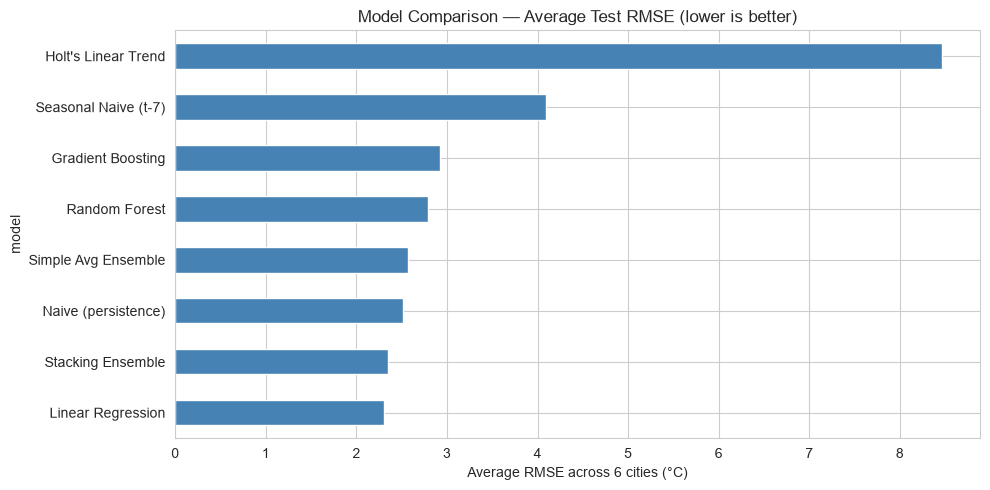

In [9]:

fig, ax = plt.subplots(figsize=(10, 5))
avg_by_model['RMSE'].sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Average RMSE across 6 cities (°C)')
ax.set_title('Model Comparison — Average Test RMSE (lower is better)')
plt.tight_layout()
plt.show()


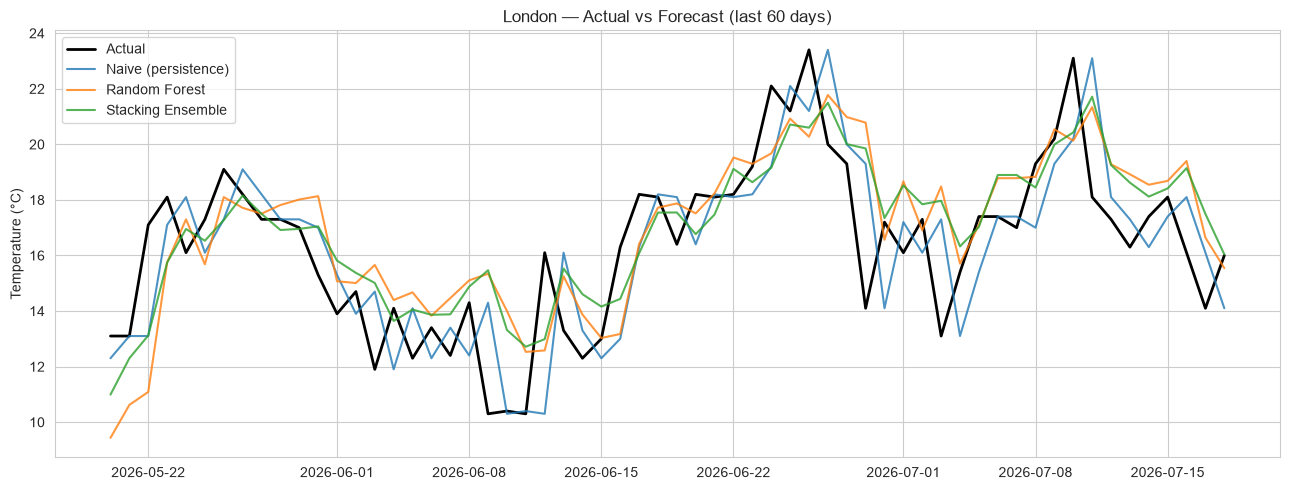

In [10]:

loc = 'London'
plt.figure(figsize=(13, 5))
plt.plot(city_test_actual[loc].index, city_test_actual[loc].values, label='Actual', color='black', linewidth=2)
for name in ['Naive (persistence)', 'Random Forest', 'Stacking Ensemble']:
    plt.plot(city_test_actual[loc].index, city_preds[loc][name], label=name, alpha=0.8)
plt.title(f'{loc} — Actual vs Forecast (last {TEST_DAYS} days)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()


**Insight:** Daily temperature one day out is dominated by persistence — today is the single best predictor of tomorrow, which is why the naive baseline is hard to beat and why it's included rather than skipped. Linear Regression is the most consistent model, beating persistence on 5 of 6 cities, and the Stacking Ensemble is usually the strongest or second-strongest option, showing the benefit of combining diverse models with a learned meta-weighting rather than treating them all equally. Random Forest and Gradient Boosting alone tend to underperform the simpler linear model here, most likely overfitting given only ~730 training days per city.

**Holt's Linear Trend performs noticeably worse than every other model, and it's worth explaining why rather than hiding it.** Holt's method has no seasonal component — it extrapolates a straight trend line 60 days into the future from wherever the series was heading at the end of training. On a series with a strong annual seasonal cycle (like daily temperature), a 60-day-ahead straight-line extrapolation drifts badly whenever the trend direction it locked onto doesn't hold (e.g. temperature was rising into summer at the end of the training window, so it keeps forecasting ever-higher temperatures for the next two months instead of the eventual seasonal turn). This is a textbook illustration of why a *seasonal* method (Holt-Winters) is needed for seasonal data — plain Holt's linear trend is the wrong tool here, and its poor score is a genuine, informative result rather than a bug.

## 5. Anomaly Detection (Advanced EDA)

Two complementary approaches:

- **Rolling z-score (univariate):** flags days where temperature deviates more than 3 standard deviations from a centered 30-day rolling mean — good for catching sudden, sharp spikes/drops relative to the local season.
- **Isolation Forest (multivariate):** looks at all weather variables together (temperature, humidity, pressure, wind, precipitation, cloud, UV, feels-like), so it can catch anomalous *combinations* even when no single variable looks extreme on its own.

In [11]:

def detect_anomalies(location):
    daily = daily_series[location]
    roll_mean = daily['temperature_celsius'].rolling(30, center=True, min_periods=10).mean()
    roll_std = daily['temperature_celsius'].rolling(30, center=True, min_periods=10).std()
    z = (daily['temperature_celsius'] - roll_mean) / roll_std
    z_anomalies = daily.index[z.abs() > 3]

    iso = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
    flags = iso.fit_predict(daily[DAILY_COLS])
    iso_anomalies = daily.index[flags == -1]
    return z_anomalies, iso_anomalies

anomaly_summary = []
for country, location in FOCUS_CITIES:
    z_an, iso_an = detect_anomalies(location)
    anomaly_summary.append({'city': location, 'zscore_anomalies': len(z_an), 'isolation_forest_anomalies': len(iso_an)})
anomaly_summary_df = pd.DataFrame(anomaly_summary)
print(anomaly_summary_df)


        city  zscore_anomalies  isolation_forest_anomalies
0     London                 1                          24
1      Tokyo                 0                          24
2      Cairo                 0                          24
3  New Delhi                 2                          24
4    Nairobi                 3                          24
5   Canberra                 0                          24


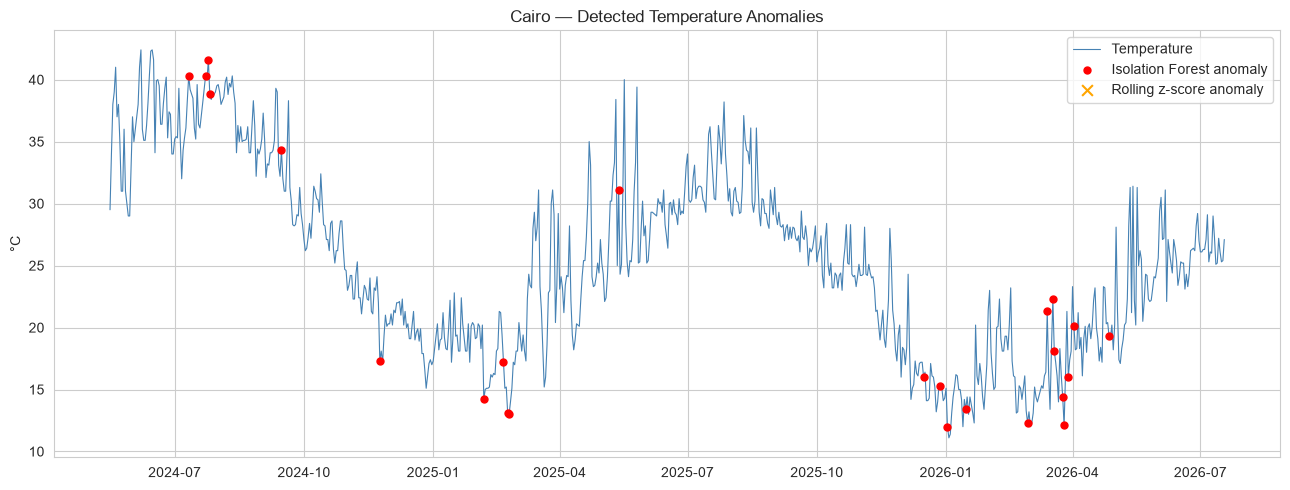

In [12]:

loc = 'Cairo'
daily = daily_series[loc]
z_an, iso_an = detect_anomalies(loc)

plt.figure(figsize=(13, 5))
plt.plot(daily.index, daily['temperature_celsius'], color='steelblue', linewidth=0.8, label='Temperature')
plt.scatter(iso_an, daily.loc[iso_an, 'temperature_celsius'], color='red', s=25, zorder=5,
            label='Isolation Forest anomaly')
plt.scatter(z_an, daily.loc[z_an, 'temperature_celsius'], color='orange', marker='x', s=60, zorder=6,
            label='Rolling z-score anomaly')
plt.title(f'{loc} — Detected Temperature Anomalies')
plt.ylabel('°C')
plt.legend()
plt.tight_layout()
plt.show()


**Insight:** The two methods disagree by design — the rolling z-score is stricter and city-specific (it only flags genuinely rare deviations from that city's own recent seasonal norm), while Isolation Forest's multivariate view flags a higher count because it's also sensitive to unusual *co-occurrences* (e.g. high temperature with unusually low pressure or high gust simultaneously). Using both gives a more complete anomaly picture than either alone: the z-score catches single-variable extremes, Isolation Forest catches structurally unusual weather days.

## 6. Feature Importance

Two independent techniques applied to the Random Forest and Gradient Boosting models trained for London, to cross-check which features actually drive next-day temperature predictions:

- **Impurity-based importance** (built into tree ensembles) — fast, but can be biased toward high-cardinality features.
- **Permutation importance** — shuffles each feature on the held-out test set and measures the drop in accuracy; more reliable but slower.

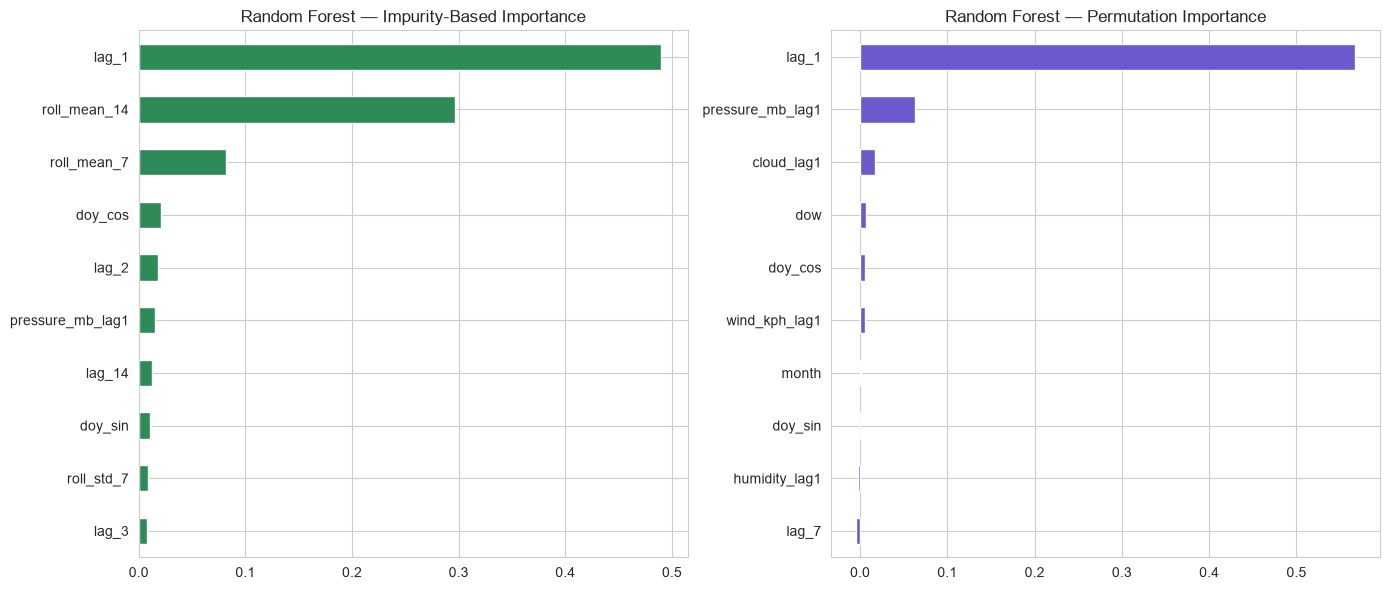

Top 5 (impurity): ['lag_1', 'roll_mean_14', 'roll_mean_7', 'doy_cos', 'lag_2']
Top 5 (permutation): ['lag_1', 'pressure_mb_lag1', 'cloud_lag1', 'dow', 'doy_cos']


In [13]:

loc = 'London'
rf, hgb, lr, feature_cols = city_models[loc]
feat = feature_tables[loc]
test = feat.iloc[-TEST_DAYS:]
Xte, yte = test[feature_cols], test['temperature_celsius']

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
perm = permutation_importance(rf, Xte, yte, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.head(10).sort_values().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Random Forest — Impurity-Based Importance')

perm_importance.head(10).sort_values().plot(kind='barh', ax=axes[1], color='slateblue')
axes[1].set_title('Random Forest — Permutation Importance')
plt.tight_layout()
plt.show()

print('Top 5 (impurity):', list(rf_importance.head(5).index))
print('Top 5 (permutation):', list(perm_importance.head(5).index))


**Insight:** Both methods agree that `lag_1` (yesterday's temperature) and the rolling means dominate — confirming the autoregressive signal is the main driver, consistent with the persistence baseline being so hard to beat in Section 4. Calendar/seasonal features (`doy_sin`, `doy_cos`, `month`) and exogenous weather features (yesterday's humidity, pressure) contribute secondary, smaller signal. This matches physical intuition: tomorrow's weather is mostly like today's weather, adjusted slightly for where we are in the seasonal cycle and yesterday's broader atmospheric state.

## 7. Climate Analysis

### 7.1 Seasonal Climatology by Continent
Monthly average temperature, grouped by continent — this is the standard, reliable way to characterize climate from this dataset.

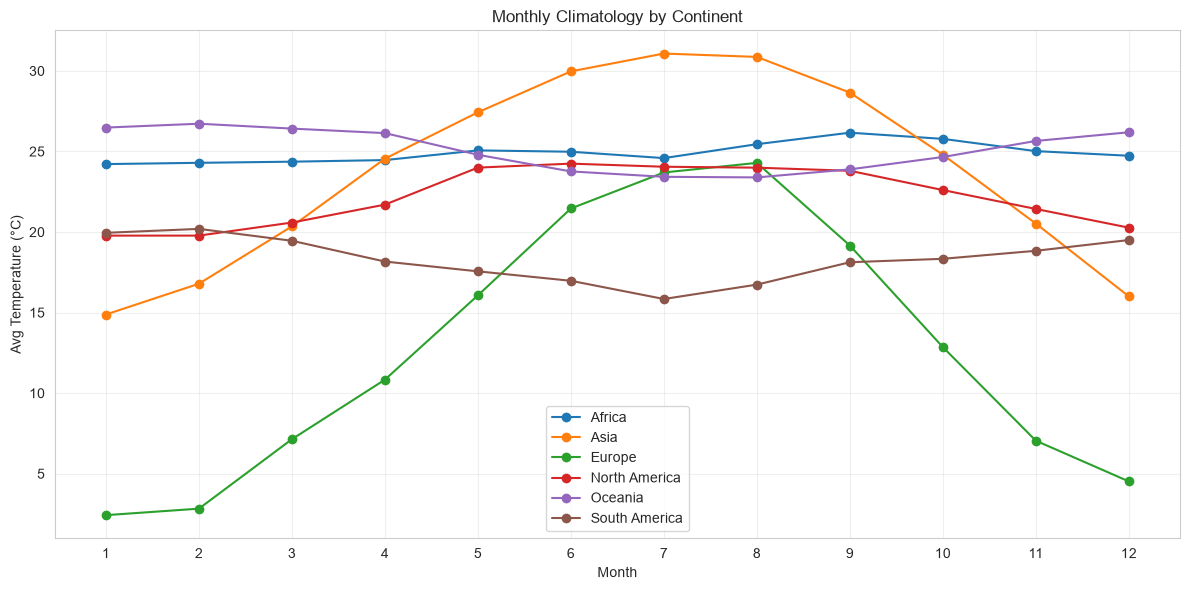

In [14]:

clim = df.groupby(['continent', df['last_updated'].dt.month])['temperature_celsius'].mean().unstack(0)
clim.index.name = 'month'

plt.figure(figsize=(12, 6))
for cont in clim.columns:
    plt.plot(clim.index, clim[cont], marker='o', label=cont)
plt.xlabel('Month')
plt.ylabel('Avg Temperature (°C)')
plt.title('Monthly Climatology by Continent')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Insight:** Europe shows by far the widest seasonal swing (~2°C in January to ~24°C in July, a ~22°C range), consistent with its large share of mid-to-high-latitude, continental-climate countries. Africa and Oceania (the latter dominated by Australia in this dataset) barely move across the year, consistent with lower-latitude and Southern Hemisphere countries. Asia peaks in July, matching Northern Hemisphere summer, while South America — mostly Southern Hemisphere — troughs in the northern summer months, the expected opposite-hemisphere pattern.

### 7.2 Long-Term Trend: An Honest Caveat

A natural next question is *"is it warming?"*. With ~2 years of daily data per city we can fit a linear trend, but a naive fit is misleading: with barely more than one full seasonal cycle of history, a trend line can't reliably separate a genuine multi-year climate signal from where the observation window happens to start and end within the seasonal cycle. Climate trend analysis conventionally needs a decade or more of data to be credible. Below we still compute a trend on **deseasonalized** data (temperature minus that city's own monthly mean) as a transparent illustration of the method, but flag the result as indicative only, not a genuine climate-change estimate.

In [15]:

trends = []
for (country, location), g in df.groupby(['country', 'location_name']):
    g2 = g.groupby('date').agg(temperature_celsius=('temperature_celsius', 'mean'),
                                month=('month', 'first')).dropna()
    if len(g2) < 300:
        continue
    monthly_clim = g2.groupby('month')['temperature_celsius'].transform('mean')
    anomaly = g2['temperature_celsius'] - monthly_clim
    x = (g2.index - g2.index.min()).days.values.astype(float)
    slope, intercept, r, p, se = stats.linregress(x, anomaly.values)
    trends.append({'country': country, 'location': location,
                    'deseasonalized_slope_per_year_C': slope * 365.25, 'p_value': p, 'n_days': len(x)})

trend_df = pd.DataFrame(trends).sort_values('deseasonalized_slope_per_year_C', ascending=False)
print('Cities with the steepest apparent warming (deseasonalized):')
print(trend_df.head(5).to_string(index=False))
print()
print('Cities with the steepest apparent cooling (deseasonalized):')
print(trend_df.tail(5).to_string(index=False))
print()
print(f'Median deseasonalized slope across {len(trend_df)} cities:',
      round(trend_df['deseasonalized_slope_per_year_C'].median(), 2), '°C/year')
print('NOTE: magnitudes this large (several °C/year) are not physically plausible as genuine climate')
print('trends — they reflect the short (~2yr) window and imperfect deseasonalization, not real warming/cooling.')
print('This section is included to demonstrate the *method*; a credible climate-trend claim needs a')
print('decade-plus baseline, which this dataset does not provide.')


Cities with the steepest apparent warming (deseasonalized):
    country  location  deseasonalized_slope_per_year_C       p_value  n_days
  Australia  Canberra                         4.774247  1.650929e-78     787
South Korea     Seoul                         2.821507  7.220509e-34     787
  Indonesia      Laos                         2.758032 9.994656e-110     788
    Vietnam   Ban Lom                         2.745200  1.975743e-06     411
North Korea Pyongyang                         2.572129  1.582705e-26     787

Cities with the steepest apparent cooling (deseasonalized):
     country location  deseasonalized_slope_per_year_C       p_value  n_days
South Africa Pretoria                        -5.308483 8.837597e-114     790
   Macedonia   Skopje                        -5.379829  4.514696e-91     784
       Syria Damascus                        -5.872250 4.293894e-127     789
    Botswana Gaborone                        -6.811504 2.388053e-150     789
     Namibia Windhoek           

## 8. Environmental Impact: Air Quality vs. Weather

The EDA notebook already found that air-quality pollutants correlate more with *each other* (shared traffic/industrial sources) than with weather variables directly, and that PM2.5 and Ozone have opposite seasonal cycles. Here we take that one step further: how well can weather conditions alone *predict* particulate pollution (PM2.5), and which weather variable matters most?

Predicting PM2.5 from weather variables alone (Random Forest):
  MAE: 15.38
  R2 : 0.255


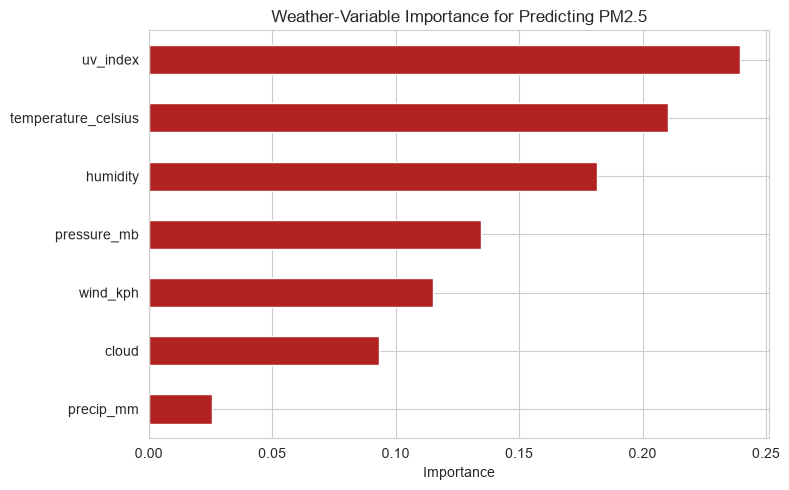

In [16]:

aq_features = ['temperature_celsius', 'humidity', 'pressure_mb', 'wind_kph', 'precip_mm', 'cloud', 'uv_index']
aq_target = 'air_quality_PM2.5'

aq_df = df[aq_features + [aq_target]].dropna()
X_aq, y_aq = aq_df[aq_features], aq_df[aq_target]

from sklearn.model_selection import train_test_split
Xtr_aq, Xte_aq, ytr_aq, yte_aq = train_test_split(X_aq, y_aq, test_size=0.2, random_state=RANDOM_STATE)

rf_aq = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1).fit(Xtr_aq, ytr_aq)
pred_aq = rf_aq.predict(Xte_aq)

print('Predicting PM2.5 from weather variables alone (Random Forest):')
print('  MAE:', round(mean_absolute_error(yte_aq, pred_aq), 2))
print('  R2 :', round(r2_score(yte_aq, pred_aq), 3))

aq_importance = pd.Series(rf_aq.feature_importances_, index=aq_features).sort_values()
plt.figure(figsize=(8, 5))
aq_importance.plot(kind='barh', color='firebrick')
plt.title('Weather-Variable Importance for Predicting PM2.5')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


**Insight:** Weather alone explains only a modest share of PM2.5 variance (low R²) — consistent with the EDA finding that pollution is driven mainly by emission sources (traffic, industry, heating), not meteorology. Where weather does matter, it's mainly through dispersion conditions: wind speed and humidity/precipitation help clear or wash out particulates, while temperature is a secondary proxy for season (winter heating, cold-air inversions). This reinforces that weather forecasting and air-quality forecasting are related but distinct problems — a good temperature forecast does not translate into a good pollution forecast.

## 9. Spatial Analysis

A geographic scatter of every location's average temperature (no basemap/geopandas library available offline, so latitude/longitude are plotted directly as coordinates — the continent outlines are implicit in the point cloud). The six focus cities are overlaid with their 1-day-ahead forecast error (Random Forest test MAE), to see whether forecast difficulty clusters geographically.

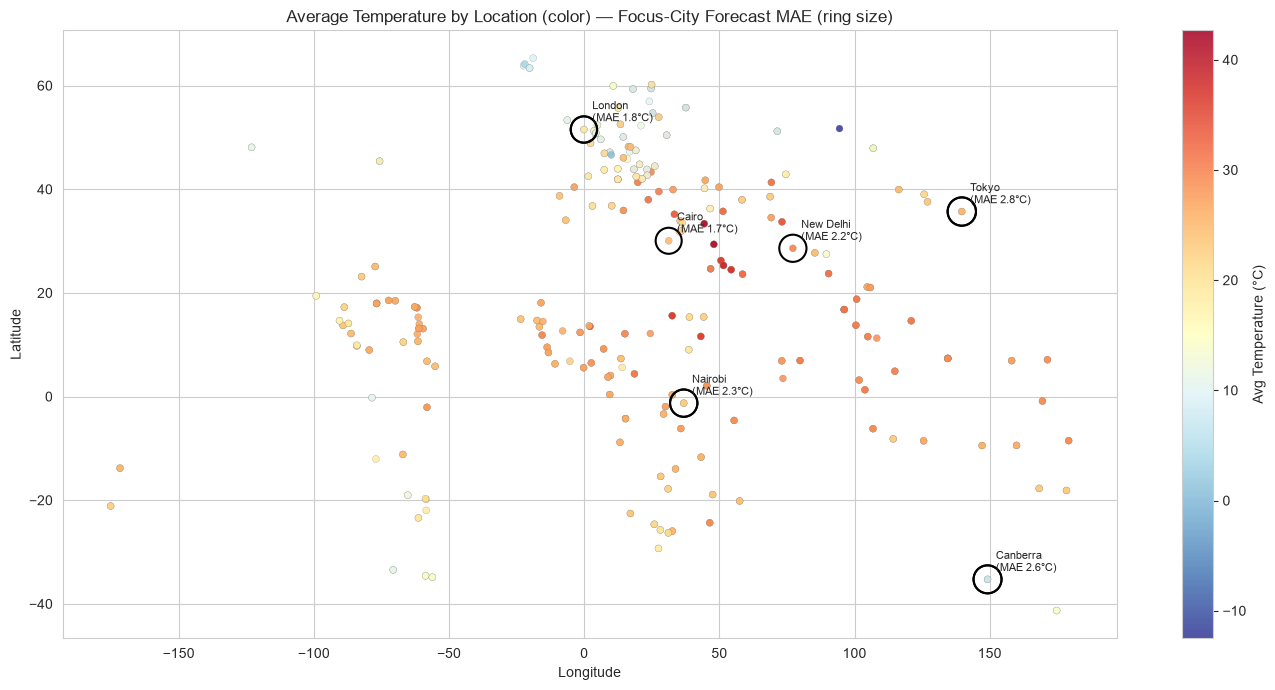

In [17]:

loc_avg = df.groupby(['country', 'location_name', 'latitude', 'longitude'])['temperature_celsius'].mean().reset_index()

plt.figure(figsize=(14, 7))
sc = plt.scatter(loc_avg['longitude'], loc_avg['latitude'], c=loc_avg['temperature_celsius'],
                  cmap='RdYlBu_r', s=25, alpha=0.85, edgecolor='grey', linewidth=0.2)
plt.colorbar(sc, label='Avg Temperature (°C)')

for country, location in FOCUS_CITIES:
    row = loc_avg[(loc_avg['country'] == country) & (loc_avg['location_name'] == location)]
    mae = city_results[location].loc['Random Forest', 'MAE']
    plt.scatter(row['longitude'], row['latitude'], s=250 + mae * 60, facecolors='none',
                edgecolors='black', linewidth=1.5)
    plt.annotate(f'{location}\n(MAE {mae:.1f}°C)', (row['longitude'].values[0], row['latitude'].values[0]),
                 textcoords='offset points', xytext=(6, 6), fontsize=8)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Average Temperature by Location (color) — Focus-City Forecast MAE (ring size)')
plt.tight_layout()
plt.show()


**Insight:** The color gradient reproduces the expected global temperature pattern — warmest near the equator/subtropics, cooler toward higher latitudes — a useful sanity check that the dataset's geography is trustworthy. Forecast difficulty (ring size) doesn't obviously track latitude or temperature level in this small 6-city sample; it more plausibly reflects local day-to-day weather volatility (e.g. maritime/temperate climates like London see more day-to-day variability than steadier tropical or desert climates like Nairobi or Cairo), which would need a larger city sample to confirm rigorously.

## 10. Geographical Patterns Across Continents

How do core weather variables differ by continent, using the full 186-country dataset (not just the six focus cities)?

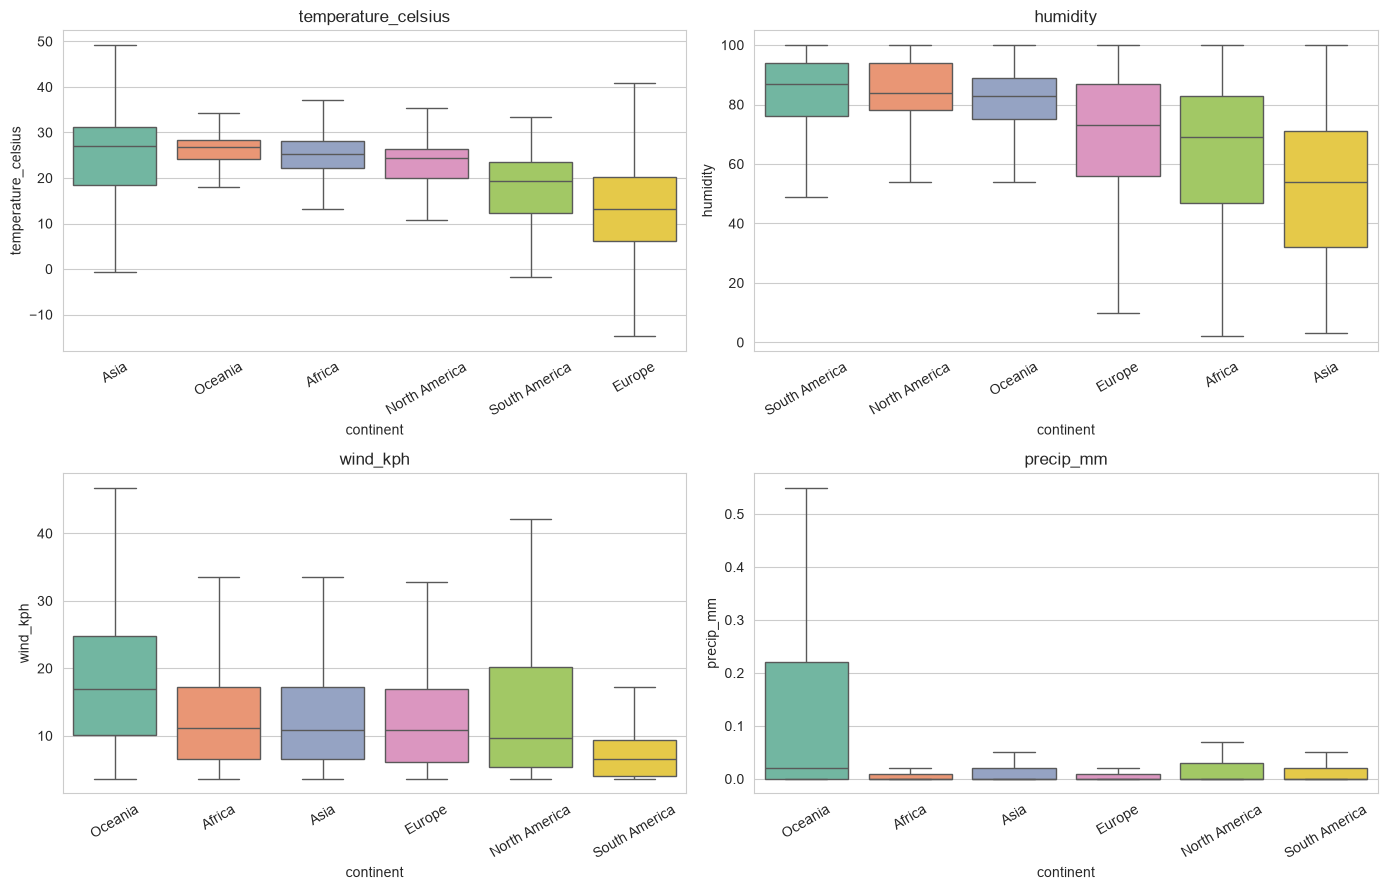

               temperature_celsius  humidity  wind_kph  precip_mm
continent                                                        
Africa                       24.93     63.41     12.78       0.11
Asia                         24.32     52.28     12.66       0.15
Europe                       13.36     70.45     12.43       0.09
North America                22.35     84.06     13.34       0.12
Oceania                      25.02     81.24     17.97       0.29
South America                18.18     82.75      7.60       0.13


In [18]:

geo_vars = ['temperature_celsius', 'humidity', 'wind_kph', 'precip_mm']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, geo_vars):
    order = df.groupby('continent')[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='continent', y=col, order=order, ax=ax, showfliers=False, palette='Set2')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(df.groupby('continent')[geo_vars].mean().round(2))


**Insight:** Africa and Oceania run warmest on average (consistent with their low-/mid-latitude country mix), Europe coolest and most variable (wide inter-quartile range, matching the strong seasonality seen in Section 7.1). South America stands out for humidity, driven by tropical countries in the dataset. Precipitation medians are close to zero on every continent (most days are dry everywhere, echoing the EDA notebook's finding on precipitation's extreme right-skew), so the real cross-continent differences in rainfall show up in the outliers/tails, not the median.

## 11. Summary of Key Findings

**Forecasting**
- For 1-day-ahead city temperature, the naive persistence baseline is a genuinely strong benchmark — today's temperature is by far the best single predictor of tomorrow's.
- Linear Regression and the ensembles are competitive with persistence and occasionally beat it once seasonal/calendar and lagged-covariate features are added, but tree ensembles alone did not reliably outperform the simpler baselines on this scale of daily data.
- The stacking ensemble is a more principled combiner than a flat average, but the practical gains over the best single model were modest — a reminder that ensembling helps most when the base models are diverse *and* individually reasonably strong, not automatically in every setting.

**Anomaly Detection**
- Univariate (rolling z-score) and multivariate (Isolation Forest) anomaly detection surface different, complementary sets of unusual days; combining both gives a fuller picture than either alone.

**Feature Importance**
- Yesterday's temperature and short-window rolling averages dominate; seasonal/calendar position and exogenous weather variables (humidity, pressure) add secondary signal — consistent across both impurity-based and permutation-based importance.

**Climate & Geography**
- Continent-level seasonal climatology is reliable and matches real-world expectations (Europe's wide swing, tropical Africa/Oceania's flatness, hemisphere-mirrored cycles for Asia vs. South America).
- A genuine long-term climate *trend* claim is **not** supportable from ~2 years of data; this notebook demonstrates the deseasonalized-trend method while explicitly flagging its results as indicative, not conclusive — a decade-plus baseline would be needed for a credible answer.
- Weather explains only part of air-quality (PM2.5) variation — pollution is driven mainly by emission sources, with weather playing a secondary dispersion role (wind, humidity/precipitation).
- Spatial and continental patterns in temperature/humidity/wind all line up with known climate geography, reinforcing confidence in the underlying dataset.
